<div style="text-align:center; margin-top:60px;">

<p style="font-size:18px;">Universidad Tecnológica Nacional</p>
<p style="font-size:18px;">Facultad Regional Córdoba</p>

<hr style="width:45%; border:1px solid #003b71; margin-top:40px; margin-bottom:30px;">

<h1 style="color:#003b71;">Trabajo Integrador</h1>
<h2 style="color:#003b71;">Compensación por Asignacion de Polos</h2>
<h3 style="color:#0057a8;">Análisis, diseño y validación de compensador</h3>

<hr style="width:45%; border:1px solid #003b71; margin-top:30px; margin-bottom:40px;">

<table style="margin-left:auto; margin-right:auto; font-size:16px;">
<tr><td><b>Materia:</b></td><td>Instrumentación y Control de Procesos</td></tr>
<tr><td><b>Carrera:</b></td><td>Lic. en Automatización y Control</td></tr>
<tr><td><b>Autor:</b></td><td>Gonzalo Vera</td></tr>
<tr><td><b>Fecha:</b></td><td>Mayo 2026</td></tr>
</table>

<br><br>

<p><b>Repositorio de referencia:</b></p>
<p>https://github.com/Automatizacion-y-Control/INT_Instrumentacion_y_Control_UTN.git</p>

</div>

# Informe técnico  
## ¿Existe un compensador mejor para la planta dada?

### Planta

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

### Pregunta de análisis

El compensador de primer orden diseñado a partir de la consigna cumple formalmente:

$$
\zeta = 0.628
$$

$$
\omega_n = 21.324 \; rad/s
$$

$$
K_v = 3
$$

Sin embargo, aparece un polo real lento que domina parcialmente la respuesta.

Este informe analiza si existe una alternativa de compensación que salve mejor los defectos de la planta.

## Índice

1. Planteo del problema  
2. Planta original y defectos principales  
3. Compensador de la consigna: interpretación  
4. Problema detectado: polo lento no deseado  
5. Qué significa “mejor” en control  
6. Alternativas posibles  
7. Propuesta: compensador dinámico de segundo orden  
8. Diseño por asignación de polos  
9. Verificación de \(K_v\)  
10. Comparación temporal  
11. Comparación ante rampa  
12. Comparación frecuencial  
13. Riesgos de la propuesta  
14. Discusión técnica  
15. Conclusión

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 1. Planteo del problema

La planta original es de tipo 1 debido al integrador en el origen.

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

Esto le da una propiedad favorable:

- error nulo ante escalón en lazo cerrado;

pero una limitación importante:

- error finito ante rampa, gobernado por \(K_v\).

La consigna original pide simultáneamente una especificación transitoria y una especificación estacionaria.

El problema detectado es que el compensador de primer orden permite cumplir algebraicamente, pero introduce un polo lento que puede dominar la respuesta.

In [2]:
# Planta original
num_p = np.array([1, 40], dtype=float)
den_p = np.array([1, 60, 875, 0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

print("Polos de la planta:", np.roots(den_p))
print("Ceros de la planta:", np.roots(num_p))

Kv_p = 40/(25*35)
print("Kv natural de la planta:", Kv_p)
print("Error ante rampa sin ganancia:", 1/Kv_p)

Polos de la planta: [-35. -25.   0.]
Ceros de la planta: [-40.]
Kv natural de la planta: 0.045714285714285714
Error ante rampa sin ganancia: 21.875


# 2. Planta original y defectos principales

La planta posee:

$$
p_1=0,\quad p_2=-25,\quad p_3=-35
$$

y:

$$
z_1=-40
$$

## Defectos principales

1. \(K_v\) natural bajo.
2. Dependencia fuerte de la ganancia para mejorar seguimiento de rampa.
3. Imposibilidad de fijar transitorio y error estacionario usando solo ganancia.
4. La planta es de orden superior respecto de un modelo simple de segundo orden.
5. El integrador mejora error ante escalón, pero agrega fase negativa.

# 3. Compensador de primer orden asociado a la consigna

El compensador obtenido previamente fue:

$$
G_{c1}(s)=337.944\frac{s+0.9299}{s+4.7886}
$$

Tiene:

- cero en \(-0.9299\);
- polo en \(-4.7886\).

Como el cero está más cerca del origen que el polo, se clasifica como compensador de adelanto.

$$
0.9299 < 4.7886
$$

Por lo tanto:

$$
G_{c1}(s)
$$

es un compensador de adelanto.

In [3]:
# Requerimientos
zeta = 0.628
wn = 21.324
Kv_req = 3

# Compensador de primer orden encontrado previamente
Kc1 = 337.944409
a1 = 0.929892
b1 = 4.788596

num_c1 = np.array([Kc1, Kc1*a1])
den_c1 = np.array([1, b1])

def closed_loop(num_ol, den_ol):
    den_cl = np.polyadd(den_ol, num_ol)
    num_cl = num_ol
    return signal.TransferFunction(num_cl, den_cl), num_cl, den_cl

def series(num1, den1, num2, den2):
    return np.polymul(num1, num2), np.polymul(den1, den2)

num_ol_c1, den_ol_c1 = series(num_c1, den_c1, num_p, den_p)
T_c1, num_cl_c1, den_cl_c1 = closed_loop(num_ol_c1, den_ol_c1)

print("Compensador C1:")
print("Numerador:", num_c1)
print("Denominador:", den_c1)
print("Polos CL:", np.roots(den_cl_c1))
print("Kv C1:", Kc1*(a1/b1)*40/875)

Compensador C1:
Numerador: [337.944409   314.25180237]
Denominador: [1.       4.788596]
Polos CL: [-37.2638077  +0.j         -13.39147162+16.59462095j
 -13.39147162-16.59462095j  -0.74184506 +0.j        ]
Kv C1: 3.000001812628675


# 4. Problema detectado: polo lento no deseado

Los polos de lazo cerrado con el compensador de primer orden incluyen aproximadamente:

$$
s=-13.391 \pm j16.595
$$

que cumplen:

$$
\zeta=0.628
$$

$$
\omega_n=21.324
$$

Pero también aparece un polo real cercano al origen:

$$
s\approx -0.742
$$

Ese polo es más lento que el par complejo deseado.

Por lo tanto, aunque el par requerido está presente, no domina completamente la dinámica.

# 5. Qué significa “mejor” en control

Un compensador puede considerarse mejor si:

1. cumple \(K_v=3\);
2. ubica el par complejo requerido;
3. evita polos lentos no deseados;
4. mejora la respuesta ante rampa;
5. mantiene estabilidad;
6. evita sensibilidad excesiva al ruido;
7. no depende de cancelaciones frágiles;
8. conserva márgenes razonables.

No siempre se puede cumplir todo simultáneamente.

Control automático es un problema de compromiso.

# 6. Alternativas posibles

## Alternativa A: solo ganancia proporcional

Se puede elegir:

$$
K=\frac{3}{K_{v,p}}
$$

Como:

$$
K_{v,p}=0.045714
$$

resulta:

$$
K=65.625
$$

Esto cumple \(K_v=3\), pero no permite imponer libremente \(\zeta\) y \(\omega_n\).

## Alternativa B: adelanto de primer orden

Es la solución de la consigna. Permite imponer el par complejo y \(K_v\), pero genera un polo lento.

## Alternativa C: compensador de segundo orden

Se puede usar un compensador más flexible:

$$
G_{c2}(s)=\frac{b_2s^2+b_1s+b_0}{s^2+a_1s+a_0}
$$

Esto permite más grados de libertad para ubicar polos no dominantes en mejores posiciones.

# 7. Propuesta: compensador dinámico de segundo orden

Se propone un compensador de segundo orden:

$$
G_{c2}(s)=\frac{b_2s^2+b_1s+b_0}{s^2+a_1s+a_0}
$$

El objetivo no es solamente cumplir la consigna, sino mejorar la estructura dinámica del sistema cerrado.

La ecuación característica resulta:

$$
D_p(s)A_c(s)+N_p(s)B_c(s)=0
$$

donde:

$$
A_c(s)=s^2+a_1s+a_0
$$

$$
B_c(s)=b_2s^2+b_1s+b_0
$$

# 8. Diseño por asignación de polos

Se desea conservar el par complejo pedido:

$$
s=-\zeta\omega_n\pm j\omega_n\sqrt{1-\zeta^2}
$$

y además ubicar polos reales adicionales.

Una elección posible es:

$$
p_3=-25
$$

$$
p_4=-35
$$

$$
p_5=-3.33965
$$

Esta elección produce un compensador estable y de fase mínima en la solución calculada.

> Nota: este diseño usa más grados de libertad que el compensador de primer orden, por lo que puede reducir parcialmente el problema del polo extremadamente lento.

In [4]:
# Diseño alternativo calculado por asignación de polos
# Resultado obtenido resolviendo:
# Dp(s)Ac(s) + Np(s)Bc(s) = P_deseado(s)
# con Kv = 3

# Compensador C2:
# Ac(s) = s^2 + 30.12259412 s + 506.19408207
# Bc(s) = 37.96455616 s^2 + 2277.8733693 s + 33218.98663567

num_c2 = np.array([37.96455616, 2277.8733693, 33218.98663567])
den_c2 = np.array([1, 30.12259412, 506.19408207])

num_ol_c2, den_ol_c2 = series(num_c2, den_c2, num_p, den_p)
T_c2, num_cl_c2, den_cl_c2 = closed_loop(num_ol_c2, den_ol_c2)

print("Compensador C2 propuesto:")
print("Numerador:", num_c2)
print("Denominador:", den_c2)

print("\nCeros de C2:")
print(np.roots(num_c2))

print("\nPolos de C2:")
print(np.roots(den_c2))

print("\nPolos de lazo cerrado con C2:")
print(np.roots(den_cl_c2))

Kv_c2 = (num_c2[-1]/den_c2[-1])*40/875
print("\nKv C2:", Kv_c2)

Compensador C2 propuesto:
Numerador: [   37.96455616  2277.8733693  33218.98663567]
Denominador: [  1.          30.12259412 506.19408207]

Ceros de C2:
[-34.99999998 -25.00000001]

Polos de C2:
[-15.06129706+16.71380905j -15.06129706-16.71380905j]

Polos de lazo cerrado con C2:
[-35.         +0.j         -25.         +0.j
 -13.391472  +16.59462123j -13.391472  -16.59462123j
  -3.33965012 +0.j        ]

Kv C2: 2.999999999984309


# 9. Verificación de \(K_v\)

Para el compensador de segundo orden:

$$
K_v=\lim_{s\to 0}sG_{c2}(s)G_p(s)
$$

Como:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

entonces:

$$
K_v=\frac{B_c(0)}{A_c(0)}\frac{40}{875}
$$

El diseño se eligió para obtener:

$$
K_v=3
$$

In [5]:
print("Kv requerido:", Kv_req)
print("Kv compensador C1:", Kc1*(a1/b1)*40/875)
print("Kv compensador C2:", Kv_c2)

Kv requerido: 3
Kv compensador C1: 3.000001812628675
Kv compensador C2: 2.999999999984309


# 10. Comparación temporal

Se comparan tres casos:

1. Planta con ganancia proporcional para \(K_v=3\).
2. Compensador de primer orden \(C_1(s)\).
3. Compensador de segundo orden \(C_2(s)\).

Esto permite observar la diferencia entre:

- cumplir solo error de velocidad;
- cumplir la consigna con compensador simple;
- usar más grados de libertad para mejorar la distribución de polos.

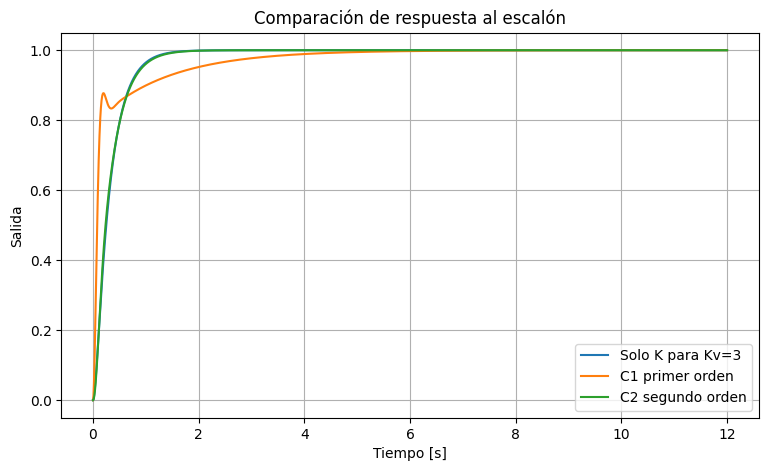


 Solo K para Kv=3
Polos: [-35.73072311 -20.72435688  -3.54492001]
{'valor_final': np.float64(0.9999999999999949), 'sobrepico_%': np.float64(2.2204460492503244e-14), 'tiempo_subida_10_90': np.float64(0.63615903975994), 'tiempo_establecimiento_2%': np.float64(1.1612903225806452)}

 C1 primer orden
Polos: [-37.2638077  +0.j         -13.39147162+16.59462095j
 -13.39147162-16.59462095j  -0.74184506 +0.j        ]
{'valor_final': np.float64(0.9999712167006902), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(0.9812453113278321), 'tiempo_establecimiento_2%': np.float64(3.177794448612153)}

 C2 segundo orden
Polos: [-35.         +0.j         -25.         +0.j
 -13.391472  +16.59462123j -13.391472  -16.59462123j
  -3.33965012 +0.j        ]
{'valor_final': np.float64(1.0000000000000115), 'sobrepico_%': np.float64(8.88178419700115e-14), 'tiempo_subida_10_90': np.float64(0.6451612903225807), 'tiempo_establecimiento_2%': np.float64(1.2033008252063015)}


In [6]:
K_prop = Kv_req / Kv_p
num_ol_K = K_prop*num_p
den_ol_K = den_p
T_K, num_cl_K, den_cl_K = closed_loop(num_ol_K, den_ol_K)

def step_info(t, y, tol=0.02):
    y = np.asarray(y)
    t = np.asarray(t)
    yf = y[-1]
    yp = np.max(y)
    Mp = np.nan if abs(yf) < 1e-12 else max(0, (yp-yf)/abs(yf)*100)

    band = tol*max(abs(yf), 1e-12)
    outside = np.where(np.abs(y-yf) > band)[0]
    ts = t[outside[-1]+1] if len(outside) and outside[-1]+1 < len(t) else t[0]

    def first_cross(level):
        idx = np.where(y >= level)[0]
        return t[idx[0]] if len(idx) else np.nan

    tr = first_cross(0.9*yf) - first_cross(0.1*yf)

    return {
        "valor_final": yf,
        "sobrepico_%": Mp,
        "tiempo_subida_10_90": tr,
        "tiempo_establecimiento_2%": ts
    }

t = np.linspace(0, 12, 4000)

systems = {
    "Solo K para Kv=3": T_K,
    "C1 primer orden": T_c1,
    "C2 segundo orden": T_c2,
}

plt.figure()
for name, sys in systems.items():
    tout, yout = signal.step(sys, T=t)
    plt.plot(tout, yout, label=name)

plt.title("Comparación de respuesta al escalón")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

for name, sys in systems.items():
    tout, yout = signal.step(sys, T=t)
    print("\n", name)
    print("Polos:", np.roots(sys.den))
    print(step_info(tout, yout))

# 11. Comparación ante rampa

Como el requerimiento incluye \(K_v=3\), la rampa es una entrada fundamental.

Para los sistemas que cumplen \(K_v=3\), se espera:

$$
e_{ss,rampa}=\frac{1}{3}=0.3333
$$

La diferencia estará más en el transitorio del error que en su valor final.

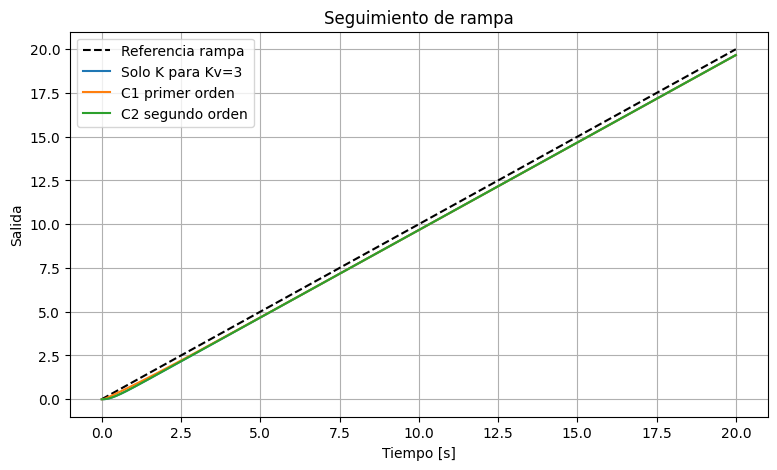

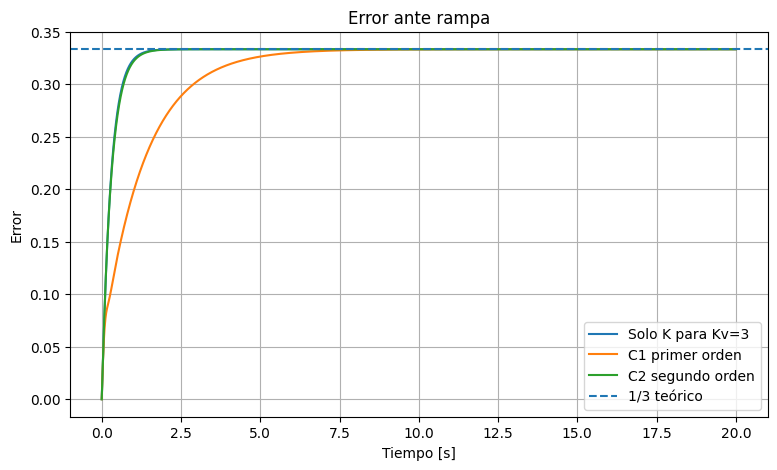

Solo K para Kv=3 error final aproximado: 0.333333333333357
C1 primer orden error final aproximado: 0.33333302927212216
C2 segundo orden error final aproximado: 0.33333333333509074


In [7]:
def simulate(sys, t, u):
    tout, y, x = signal.lsim(sys, U=u, T=t)
    return y

t_r = np.linspace(0, 20, 5000)
r = t_r

plt.figure()
plt.plot(t_r, r, "k--", label="Referencia rampa")

errors = {}

for name, sys in systems.items():
    y = simulate(sys, t_r, r)
    e = r - y
    errors[name] = e
    plt.plot(t_r, y, label=name)

plt.title("Seguimiento de rampa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

plt.figure()
for name, e in errors.items():
    plt.plot(t_r, e, label=name)

plt.axhline(1/3, linestyle="--", label="1/3 teórico")
plt.title("Error ante rampa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.legend()
plt.show()

for name, e in errors.items():
    print(name, "error final aproximado:", e[-1])

# 12. Comparación frecuencial

El análisis de Bode permite observar cómo cada compensador modifica:

- ganancia de baja frecuencia;
- fase;
- ancho de banda;
- posible sensibilidad a ruido;
- margen relativo.

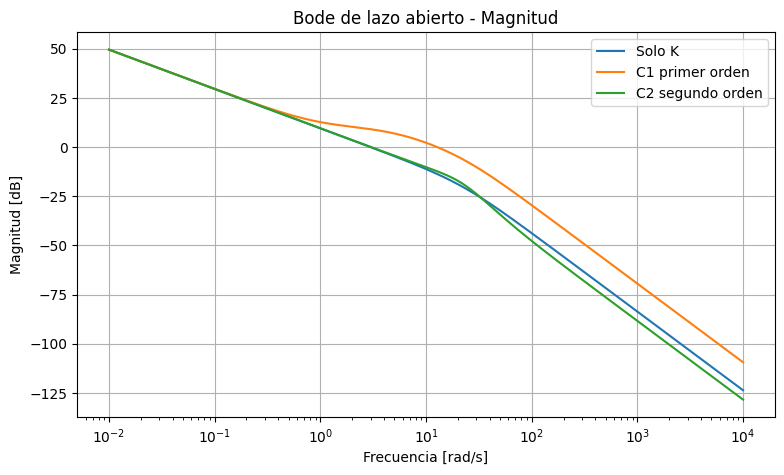

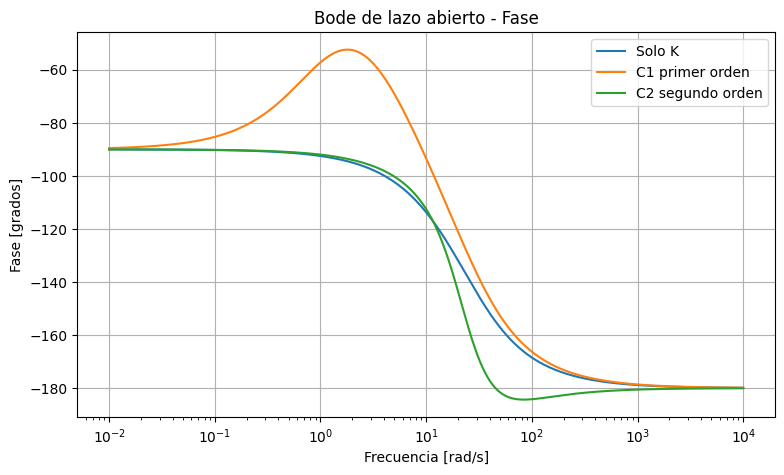

In [8]:
def bode_plot(num, den, label, w):
    sys = signal.TransferFunction(num, den)
    w, mag, phase = signal.bode(sys, w=w)
    return mag, phase

w = np.logspace(-2, 4, 4000)

open_loops = {
    "Solo K": (num_ol_K, den_ol_K),
    "C1 primer orden": (num_ol_c1, den_ol_c1),
    "C2 segundo orden": (num_ol_c2, den_ol_c2),
}

plt.figure()
for name, (num, den) in open_loops.items():
    mag, phase = bode_plot(num, den, name, w)
    plt.semilogx(w, mag, label=name)

plt.title("Bode de lazo abierto - Magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.show()

plt.figure()
for name, (num, den) in open_loops.items():
    mag, phase = bode_plot(num, den, name, w)
    plt.semilogx(w, phase, label=name)

plt.title("Bode de lazo abierto - Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [grados]")
plt.legend()
plt.show()

# 13. Riesgos de la propuesta

El compensador de segundo orden mejora ciertos aspectos, pero no es gratis.

## Riesgo 1: mayor complejidad

Se pasa de un compensador de primer orden a uno de segundo orden.

## Riesgo 2: posible cancelación de modos

El diseño propuesto genera ceros próximos a polos estables de la planta.  
Esto puede ser aceptable en simulación, pero delicado en sistemas reales con incertidumbre paramétrica.

## Riesgo 3: mayor sensibilidad

Agregar dinámica adicional puede aumentar sensibilidad a ruido o errores de modelo.

## Riesgo 4: implementación

Un compensador de orden superior requiere más cuidado en implementación digital o analógica.

# 14. Discusión técnica

El compensador de primer orden de la consigna es correcto desde el punto de vista académico porque:

- cumple \(K_v=3\);
- contiene el par complejo pedido;
- usa una estructura estándar simple;
- permite estudiar compensación por adelanto.

Pero no es necesariamente el mejor desde el punto de vista global porque aparece un polo lento.

El compensador de segundo orden propuesto usa más grados de libertad para mejorar la asignación de polos.

Esto muestra una idea importante:

> una consigna de control clásico puede tener soluciones formalmente correctas, pero no todas son equivalentes en desempeño global.

Para una planta de tercer orden, pedir solo \(\zeta\) y \(\omega_n\) de un par complejo no determina por completo la dinámica.

# 15. Conclusión

Sí, existe una alternativa que puede funcionar mejor que el compensador de primer orden: un compensador dinámico de segundo orden.

La propuesta:

$$
G_{c2}(s)=
\frac{37.9646s^2+2277.8734s+33218.9866}
{s^2+30.1226s+506.1941}
$$

cumple:

$$
K_v=3
$$

y permite ubicar el par complejo requerido, usando más grados de libertad para distribuir mejor los polos restantes.

Sin embargo, no debe interpretarse como solución perfecta. Su ventaja es pedagógica y técnica: muestra cómo agregar orden al compensador permite mejorar restricciones simultáneas. Su desventaja es mayor complejidad y posible sensibilidad ante incertidumbre.

Conclusión final:

- El compensador de primer orden es adecuado para resolver la consigna clásica.
- El compensador de segundo orden es más flexible.
- Para una solución industrial real habría que analizar robustez, incertidumbre, saturación, ruido y discretización.

# 16. Síntesis para informe académico

Una forma adecuada de redactar la comparación sería:

> El compensador de primer orden satisface las especificaciones impuestas, pero introduce un polo real lento que afecta la dominancia dinámica. Por ello se propone, como alternativa de mejora, un compensador de segundo orden obtenido por asignación de polos. Este diseño conserva el cumplimiento de \(K_v=3\) y permite una distribución más controlada de los polos de lazo cerrado. No obstante, el aumento de orden implica mayor complejidad y exige verificar robustez frente a incertidumbre del modelo.